# Credit Risk & Loan Default Prediction System
## Objective
To analyze customer financial data and build a machine learning model that predicts whether a loan
applicant is likely to default or repay the loan, helping businesses reduce financial risk and make smarter
lending decisions.


## Import Required Libraries

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


## Upload Data [CSV File]

In [24]:
df = pd.read_csv("loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


## Basic Inspection

In [25]:
df.shape

(381, 13)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [27]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [28]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

## Drop ID Column

In [29]:
df.drop('Loan_ID', axis=1, inplace=True)

## Handle Missing Values

In [30]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['ApplicantIncome'].fillna(df['ApplicantIncome'].median(), inplace=True)
df['CoapplicantIncome'].fillna(df['CoapplicantIncome'].median(), inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

## Encode Categorical Variables

In [31]:
le = LabelEncoder()

categorical_cols = [
    'Gender','Married','Dependents','Education',
    'Self_Employed','Property_Area','Loan_Status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Exploratory Data Analysis (EDA)
Loan Status Distribution

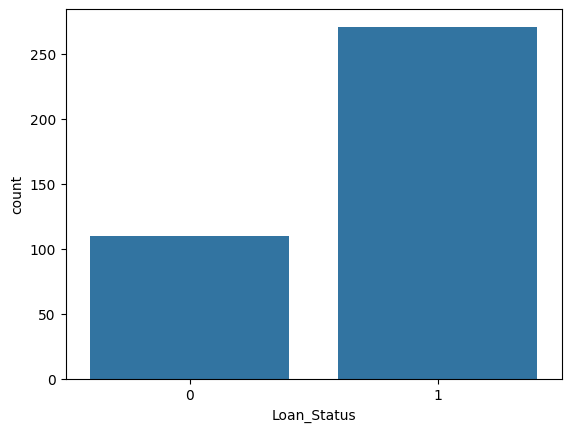

In [32]:
sns.countplot(x='Loan_Status', data=df)
plt.show()

Credit History vs Loan Status

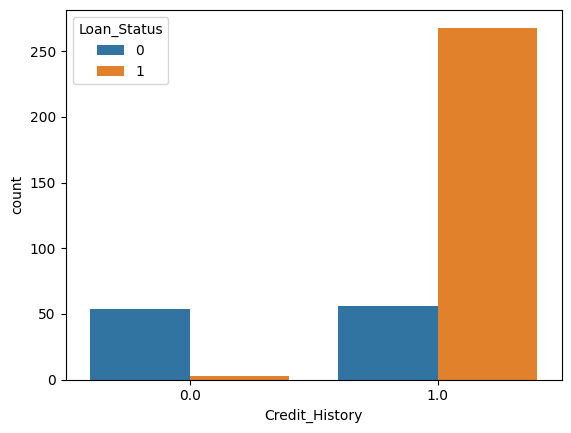

In [33]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

Correlation Heatmap

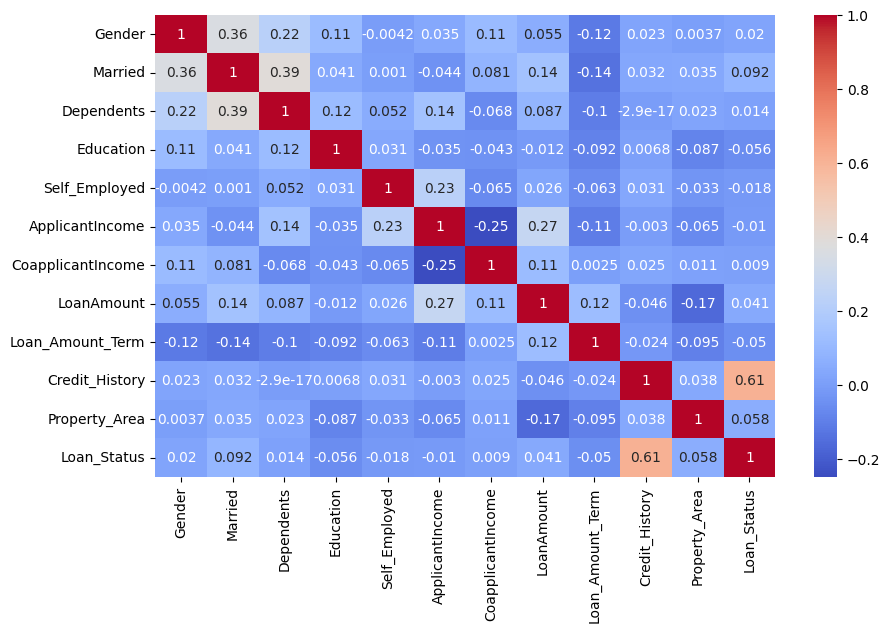

In [34]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Feature Engineering

In [35]:
df['Debt_to_Income'] = df['LoanAmount'] / (df['ApplicantIncome'] + 1)

df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['EMI_to_Income'] = df['EMI'] / (df['ApplicantIncome'] + 1)

## Feature Scaling

In [36]:
scaler = StandardScaler()

num_cols = [
    'ApplicantIncome','CoapplicantIncome','LoanAmount',
    'Loan_Amount_Term','Debt_to_Income','EMI','EMI_to_Income'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

## Train-Test Split

In [37]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

In [38]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        21
           1       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77



## Decision Tree Model

In [39]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7662337662337663
              precision    recall  f1-score   support

           0       0.60      0.43      0.50        21
           1       0.81      0.89      0.85        56

    accuracy                           0.77        77
   macro avg       0.70      0.66      0.67        77
weighted avg       0.75      0.77      0.75        77



## Random Forest Model

In [57]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8051948051948052
              precision    recall  f1-score   support

           0       0.88      0.33      0.48        21
           1       0.80      0.98      0.88        56

    accuracy                           0.81        77
   macro avg       0.84      0.66      0.68        77
weighted avg       0.82      0.81      0.77        77



## Feature Importance

In [58]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
9,Credit_History,0.294212
11,Debt_to_Income,0.110414
5,ApplicantIncome,0.104338
13,EMI_to_Income,0.102396
7,LoanAmount,0.090654
12,EMI,0.089270
6,CoapplicantIncome,0.065277
10,Property_Area,0.032483
8,Loan_Amount_Term,0.031384
2,Dependents,0.025775


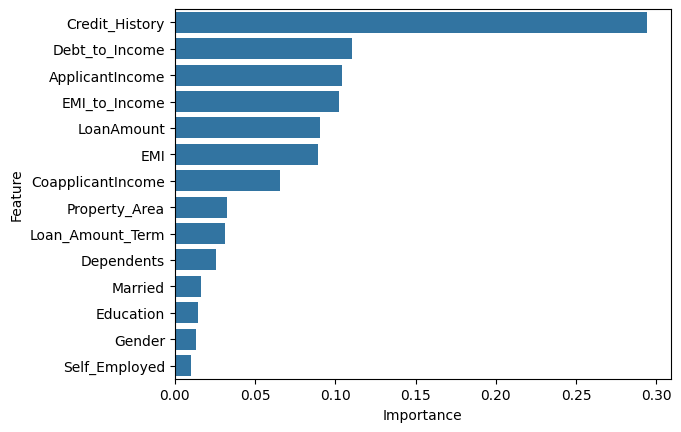

In [69]:
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.show()

## Confusion Matrix

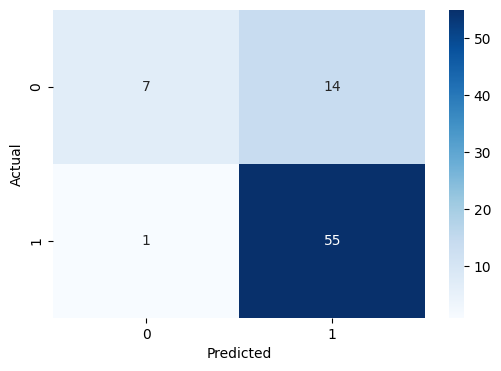

In [66]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, axes = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [60]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.818182,0.800000,1.000000,0.888889,0.617347
1,Decision Tree,0.753247,0.793651,0.892857,0.840336,0.656463
2,Random Forest,0.805195,0.797101,0.982143,0.880000,0.755102


In [62]:
comparison_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.805195,0.797101,0.982143,0.880000,0.755102
1,Decision Tree,0.753247,0.793651,0.892857,0.840336,0.656463
0,Logistic Regression,0.818182,0.800000,1.000000,0.888889,0.617347


## ROC Curve

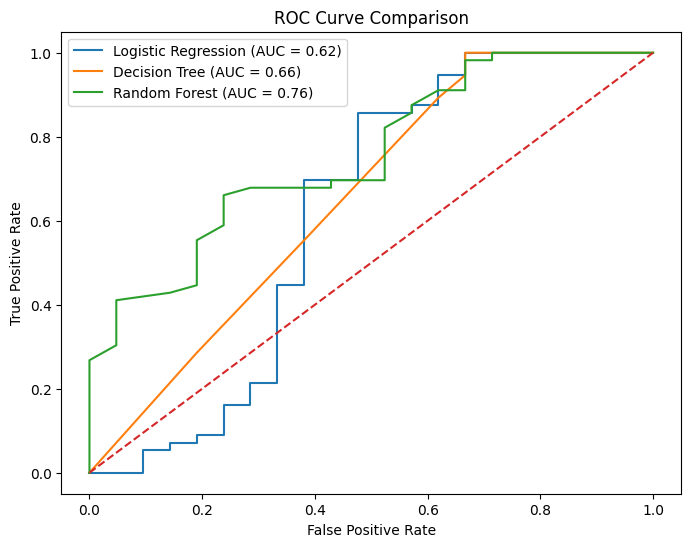

In [51]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Confusion Matrix Comparison

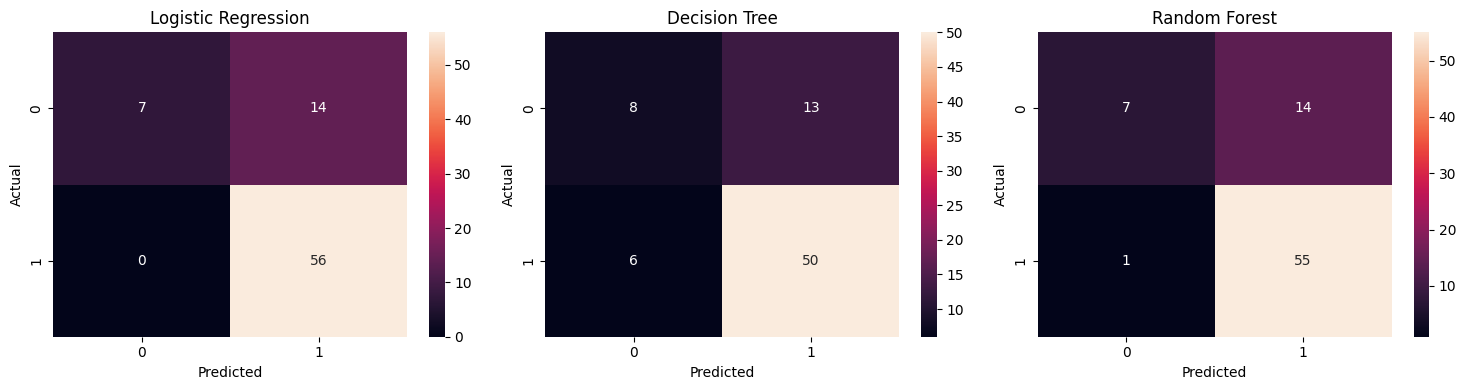

In [70]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (model_name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Final Business Recommendations

Based on exploratory data analysis, feature engineering, and machine learning model evaluation, the following recommendations are proposed for effective credit risk management:

- **Adopt Random Forest as the primary risk assessment model**, as it demonstrated the highest ROC-AUC and recall, making it more reliable in identifying risky applicants.
- **Prioritize credit history checks** during loan approval, as applicants with poor or missing credit history exhibit significantly higher default rates.
- **Introduce EMI-to-Income thresholds** to ensure loan affordability and reduce financial stress on borrowers.
- **Apply risk-based loan pricing**, where higher-risk customers are offered loans with stricter terms or higher interest rates.
- **Use machine learning predictions as a decision-support system**, not a replacement for human judgment, especially for borderline cases.

---

## Factors That Increase Loan Default Risk

The following factors were identified as key contributors to loan default:

- **Poor Credit History**  
  Applicants with weak or no credit history have a substantially higher probability of default.

- **High EMI-to-Income Ratio**  
  When monthly loan installments consume a large portion of the applicant’s income, repayment becomes difficult.

- **Low or Unstable Income**  
  Customers with low income or irregular earnings (e.g., self-employed individuals) face higher repayment uncertainty.

- **High Loan Amount Relative to Income**  
  Large loans taken without sufficient income backing increase financial burden.

- **Short Loan Tenure with High EMI**  
  Short repayment periods lead to higher monthly installments, increasing default risk.

---

## What Makes a Customer Low-Risk?

Low-risk customers generally display strong financial stability and responsible credit behavior:

- **Good Credit History**  
  A positive repayment track record strongly indicates future repayment capability.

- **Low EMI-to-Income Ratio**  
  Affordable EMIs relative to income reduce financial pressure.

- **Stable Employment and Income**  
  Salaried applicants with consistent income are less likely to default.

- **Moderate Loan Amount**  
  Loan sizes aligned with income levels lower debt burden.

- **Longer Loan Tenure**  
  Extended repayment periods help spread EMIs and improve affordability.

---

## 📌 Conclusion

The Credit Risk & Loan Default Prediction System demonstrates that combining domain-driven feature engineering with machine learning significantly improves risk assessment accuracy. By focusing on credit history, affordability metrics, and income stability, financial institutions can minimize default risk while maintaining healthy loan portfolios.
